In [17]:
from sklearn.svm import SVC
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [2]:
df = pd.read_csv("C:/Users/user/Documents/EBAC/dados/Base_M43_Pratique_LOL_RANKED_WIN.csv", delimiter=',')

df.head(10)

,gameId,blueWins,blueWardsPlaced,blueWardsDestroyed,blueFirstBlood,blueKills,blueDeaths,blueAssists,blueEliteMonsters,blueDragons,...,redTowersDestroyed,redTotalGold,redAvgLevel,redTotalExperience,redTotalMinionsKilled,redTotalJungleMinionsKilled,redGoldDiff,redExperienceDiff,redCSPerMin,redGoldPerMin
0,4519157822,0,28,2,1,9,6,11,0,0,...,0,16567,6.8,17047,197,55,-643,8,19.7,1656.7
1,4523371949,0,12,1,0,5,5,5,0,0,...,1,17620,6.8,17438,240,52,2908,1173,24.0,1762.0
2,4521474530,0,15,0,0,7,11,4,1,1,...,0,17285,6.8,17254,203,28,1172,1033,20.3,1728.5
3,4524384067,0,43,1,0,4,5,5,1,0,...,0,16478,7.0,17961,235,47,1321,7,23.5,1647.8
4,4436033771,0,75,4,0,6,6,6,0,0,...,0,17404,7.0,18313,225,67,1004,-230,22.5,1740.4
5,4475365709,1,18,0,0,5,3,6,1,1,...,0,15201,7.0,18060,221,59,-698,-101,22.1,1520.1
6,4493010632,1,18,3,1,7,6,7,1,1,...,0,14463,6.4,15404,164,35,-2411,-1563,16.4,1446.3
7,4496759358,0,16,2,0,5,13,3,0,0,...,0,17920,6.6,16938,157,54,2615,800,15.7,1792.0
8,4443048030,0,16,3,0,7,7,8,0,0,...,0,18380,7.2,19298,240,53,1979,771,24.0,1838.0
9,4509433346,1,13,1,1,4,5,5,1,1,...,0,16605,6.8,18379,247,43,1548,1574,24.7,1660.5


In [3]:
df.isnull().values.any() 

False

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9879 entries, 0 to 9878
Data columns (total 40 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   gameId                        9879 non-null   int64  
 1   blueWins                      9879 non-null   int64  
 2   blueWardsPlaced               9879 non-null   int64  
 3   blueWardsDestroyed            9879 non-null   int64  
 4   blueFirstBlood                9879 non-null   int64  
 5   blueKills                     9879 non-null   int64  
 6   blueDeaths                    9879 non-null   int64  
 7   blueAssists                   9879 non-null   int64  
 8   blueEliteMonsters             9879 non-null   int64  
 9   blueDragons                   9879 non-null   int64  
 10  blueHeralds                   9879 non-null   int64  
 11  blueTowersDestroyed           9879 non-null   int64  
 12  blueTotalGold                 9879 non-null   int64  
 13  blu

In [5]:
df.drop(columns=['gameId'], inplace=True)

In [6]:
# Sem variáveis categóricas

In [13]:
# Fazemos a matriz de correlação e analisamos as váriaveis que parecem ter maior correlação com a váriavel target.

In [32]:
correlation_matrix = df.corr()

print("\nMatriz de Correlação (Valores Numéricos):")
print(correlation_matrix)


Matriz de Correlação (Valores Numéricos):
                              blueWins  blueWardsPlaced  blueWardsDestroyed  \
blueWins                      1.000000         0.000087            0.044247   
blueWardsPlaced               0.000087         1.000000            0.034447   
blueWardsDestroyed            0.044247         0.034447            1.000000   
blueFirstBlood                0.201769         0.003228            0.017717   
blueKills                     0.337358         0.018138            0.033748   
blueDeaths                   -0.339297        -0.002612           -0.073182   
blueAssists                   0.276685         0.033217            0.067793   
blueEliteMonsters             0.221944         0.019892            0.041700   
blueDragons                   0.213768         0.017676            0.040504   
blueHeralds                   0.092385         0.010104            0.016940   
blueTowersDestroyed           0.115566         0.009462           -0.009150   
blueTotal

In [ ]:
# Criamos um novo DataFrame, mantendo apenas as colunas com maior correlação com nossa variável target

In [11]:
colunas_selecionadas = ['blueWins', 'blueFirstBlood', 'blueKills', 'blueAssists', 'blueEliteMonsters', 'blueDragons', 'blueTotalGold', 'blueAvgLevel', 'blueTotalExperience', 'blueTotalMinionsKilled', 'blueGoldDiff', 'blueExperienceDiff', 'blueCSPerMin', 'blueGoldPerMin', 'redDeaths'] 

# Cria um novo DataFrame contendo apenas as colunas selecionadas
df_corr = df[colunas_selecionadas].copy()

df_corr.head(10)

,blueWins,blueFirstBlood,blueKills,blueAssists,blueEliteMonsters,blueDragons,blueTotalGold,blueAvgLevel,blueTotalExperience,blueTotalMinionsKilled,blueGoldDiff,blueExperienceDiff,blueCSPerMin,blueGoldPerMin,redDeaths
0,0,1,9,11,0,0,17210,6.6,17039,195,643,-8,19.5,1721.0,9
1,0,0,5,5,0,0,14712,6.6,16265,174,-2908,-1173,17.4,1471.2,5
2,0,0,7,4,1,1,16113,6.4,16221,186,-1172,-1033,18.6,1611.3,7
3,0,0,4,5,1,0,15157,7.0,17954,201,-1321,-7,20.1,1515.7,4
4,0,0,6,6,0,0,16400,7.0,18543,210,-1004,230,21.0,1640.0,6
5,1,0,5,6,1,1,15899,7.0,18161,225,698,101,22.5,1589.9,5
6,1,1,7,7,1,1,16874,6.8,16967,225,2411,1563,22.5,1687.4,7
7,0,0,5,3,0,0,15305,6.4,16138,209,-2615,-800,20.9,1530.5,5
8,0,0,7,8,0,0,16401,7.2,18527,189,-1979,-771,18.9,1640.1,7
9,1,1,4,5,1,1,15057,6.8,16805,220,-1548,-1574,22.0,1505.7,4


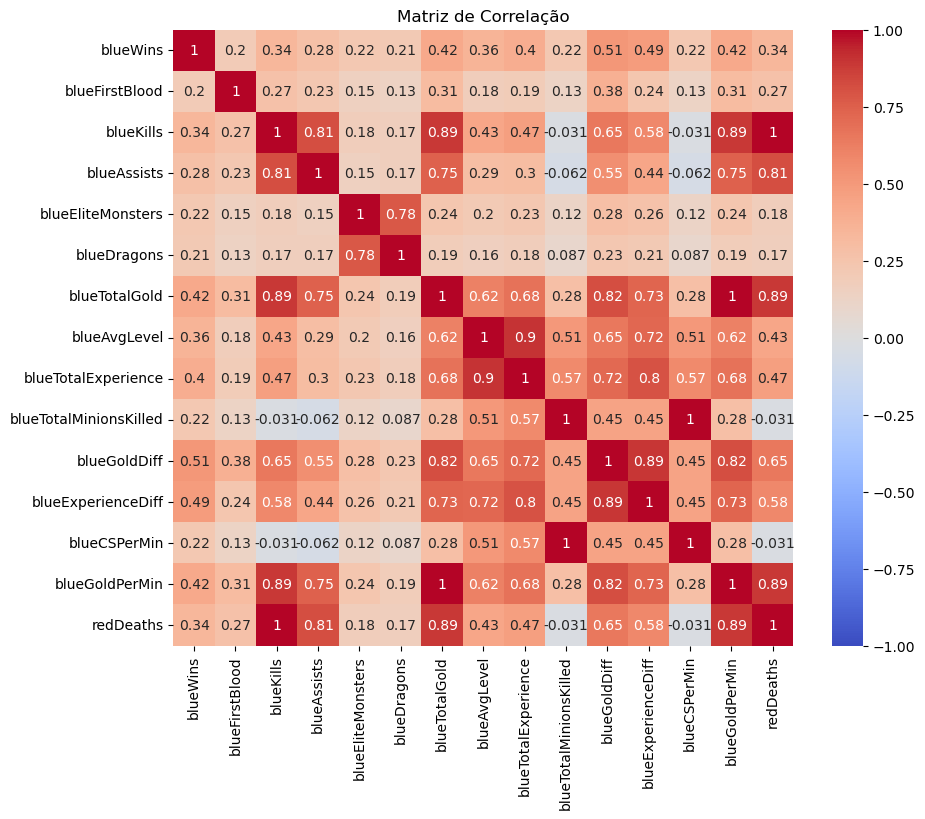

In [12]:
correlation_matrix = df_corr.corr()

# plotando a matriz de correlação usando seaborn
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matriz de Correlação')
plt.show()

In [14]:
# Padronizacao dos dados

In [15]:
df_padronizado = df_corr.copy()

In [18]:
colunas_padronizar = ['blueTotalGold', 'blueTotalExperience', 'blueTotalMinionsKilled', 'blueGoldDiff', 'blueExperienceDiff', 'blueCSPerMin', 'blueGoldPerMin'] 

# Iniciar o StandardScaler
scaler = StandardScaler()

# Ajustar e transformar os dados selecionados
df_padronizado[colunas_padronizar] = scaler.fit_transform(df[colunas_padronizar])

In [19]:
# Separação da base em X e Y e em seguida nas bases de treino e teste.

In [21]:
X = df_padronizado.drop(columns=['blueWins'])
Y = df_padronizado['blueWins']

In [22]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [23]:
# Treino o modelo SVM com sua base de treino.
# Esse modelo deve ser treinado usando o kernel linear.

In [24]:
svm_model = SVC(kernel =  'linear', random_state = 1, C = 1.0)
svm_model.fit(X_train,Y_train)

SVC(kernel='linear', random_state=1)

In [25]:
# Realize as previsões para a base de teste e traga a avaliação.

In [26]:
Y_pred = svm_model.predict(X_train)
Y_pred

array([0, 0, 0, ..., 1, 0, 0], dtype=int64)

In [27]:
report = classification_report(Y_train, Y_pred)
print("Relatório de Classificação:\n", report)

Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.73      0.74      0.73      3966
           1       0.73      0.72      0.73      3937

    accuracy                           0.73      7903
   macro avg       0.73      0.73      0.73      7903
weighted avg       0.73      0.73      0.73      7903



In [28]:
# Treine um novo modelo SVM com sua base de treino + realize as previsões e avalições.
# Esse modelo dedve ser treinado usando o kernel poly.

In [29]:
svm_model_poly = SVC(kernel =  'poly', random_state = 1, C = 1.0)
svm_model_poly.fit(X_train,Y_train)

SVC(kernel='poly', random_state=1)

In [30]:
Y_pred_poly = svm_model_poly.predict(X_train)
Y_pred_poly

array([0, 0, 1, ..., 1, 0, 0], dtype=int64)

In [31]:
report = classification_report(Y_train, Y_pred_poly)
print("Relatório de Classificação:\n", report)

Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.72      0.76      0.74      3966
           1       0.74      0.70      0.72      3937

    accuracy                           0.73      7903
   macro avg       0.73      0.73      0.73      7903
weighted avg       0.73      0.73      0.73      7903

